In [175]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re #regular expression
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


In [176]:
with zipfile.ZipFile('WELFake_Dataset.csv.zip','r') as zip_ref:
    zip_ref.extractall('data_news')

In [177]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [178]:
df = pd.read_csv('WELFake_Dataset.csv.zip')
df = df.dropna()
df = df.sample(n=10000 , random_state=42) #use 10,000 data 


In [179]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+','',text)
    text = re.sub(r'[^a-z\s]','',text)
    words = text.split()
    text = " ".join([w for w in words if w not in stop_words])
    return text
 

In [180]:
df['clean_text'] = df['text'].apply(clean_text)
X = df['clean_text'] 
y = df ['label'] # 0=fake, 1=real
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [181]:
tfidf = TfidfVectorizer(max_features=5000) #use 5000 important words
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [182]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [183]:

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))
print ("accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       977
           1       0.85      0.86      0.86      1023

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

accuracy: 0.8545
[[826 151]
 [140 883]]
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       977
           1       0.85      0.86      0.86      1023

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



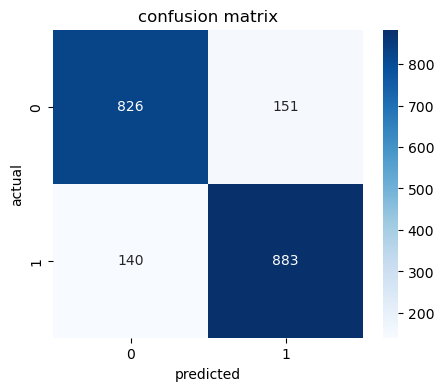

In [184]:
cm =confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

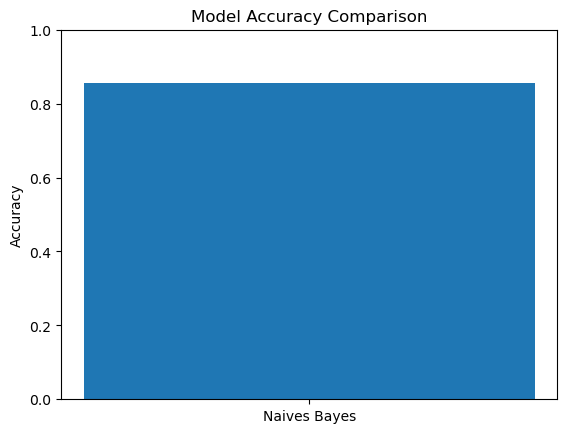

In [185]:
accuracy = accuracy_score(y_test,y_pred)
plt.bar (["Naives Bayes"],[accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

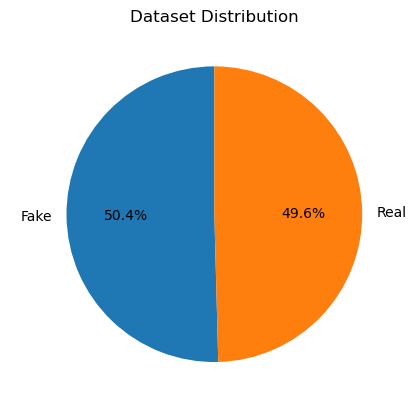

In [172]:
df['label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=["Fake","Real"],
    startangle=90
)

plt.title("Dataset Distribution")
plt.ylabel(" ")
plt.show()